In [1]:
from BoardDetection import BoardDetection
from PieceDetection.PieceCropper_3D import PieceCropper
from Dataset.DataSetLoaders.ChessDataset import ChessDataset

import os
import sys

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn import functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

from torchvision import transforms
from torchvision import models
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
import seaborn as sns

import math
import pickle
from tqdm.auto import tqdm

/mnt/D/University/Thesis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
# lookup_quads = {}

def preprocess_fn(padding=(0,0)):
    # global lookup_quads
    def main(content):
        # global lookup_quads
        img, label = content
        
        # if not(str(label["id"]) in lookup_quads):
        #     BoardDetection.board_extractor.set_img(img)
        #     try:
        #         quad, conf = BoardDetection.board_extractor.extract_board()
        #     except Exception as e:
        #         quad = label["corners"].numpy().astype(np.float32)
        #         # plt.imshow(img.permute(1,2,0));
        #         # print(label)
        #         # raise e
        #     # warpped, M = BE.warp(quad, padding=padding)

        #     lookup_quads[str(label["id"])] = quad
        
        # quad = lookup_quads[str(label["id"])]
        quad = label["corners"].numpy().astype(np.float32)

        # orig_size = label["original_img_size"]
        orig_size = None

        PieceCropper.piece_cropper.set_img(img, torch.tensor(quad))
        board_split = PieceCropper.piece_cropper.process_img(original_img_size=orig_size)

        return board_split, label

    return main

def augmentations_fn():
    transform_fns = transforms.Compose([
        # --- Geometric Augmentations ---
        transforms.RandomAffine(
            degrees=15,              # ±15° rotation
            translate=(0.05, 0.05),  # up to 5% shift in each direction
            scale=(0.9, 1.1),        # small zoom in/out
            shear=5,                 # mild shear to simulate tilt
        ),
        
        transforms.RandomPerspective(
            distortion_scale=0.2,    # controls perspective intensity
            p=0.5                    # apply 50% of the time
        ),
        
        transforms.RandomHorizontalFlip(p=0.5),  # simulate mirrored camera
        
        # --- Photometric Augmentations ---
        transforms.ColorJitter(
            brightness=0.4,          # ±40% brightness
            contrast=0.4,            # ±40% contrast
            saturation=0.3,          # ±30% saturation
            hue=0.05                 # ±5% hue shift
        ),
        
        transforms.RandomApply([transforms.GaussianBlur(kernel_size=(3, 5))], p=0.2),  # small blur
        transforms.RandomAdjustSharpness(sharpness_factor=1.5, p=0.3),        # focus variation
        transforms.RandomAutocontrast(p=0.3),                                 # exposure balance

        # --- Convert to tensor and normalize ---
        # transforms.ToTensor(),
        # transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    def main(content):
        imgs, label = content
        orig_shape = imgs.shape
        img_shape = imgs.shape[2:]
        imgs = imgs.reshape(-1,*img_shape)
        imgs = torch.stack([transform_fns(img) for img in imgs]).reshape(*orig_shape)
        return imgs, label
    return main


def post_transform(img):
    return torch.tensor(img).permute(2,0,1)

In [4]:
count_ds = ChessDataset(
    # root_dirs="/mnt/D/University/Thesis_Dataset/Cropped_Dataset/",
    config={
        "img_size": (320,320)
    },
    force_build_pkl=True
)

occupancy_count = 0
occupied_count = 0
white_count = 0
piece_counts = {
    "P": 0,
    "N": 0,
    "B": 0,
    "R": 0,
    "Q": 0,
    "K": 0
}
piece_types = ['P', 'N', 'B', 'R', 'Q', 'K']
for y in count_ds.labels:
    board: torch.Tensor = y["board_tensor"]
    occupancy_count += 64
    occupied_count += (board != 12).sum().item()
    white_count += (board < 6).sum().item()
    for i, piece_type in enumerate(piece_types):
        piece_counts[piece_type] += ((board == i) | (board == i+6)).sum().item()

occupancy_count, occupied_count, white_count, piece_counts

(64320,
 21792,
 10837,
 {'P': 11314, 'N': 2014, 'B': 2034, 'R': 2995, 'Q': 1428, 'K': 2007})

('/mnt/D/University/Thesis_Dataset/Dataset/Images/image_280.jpg',
 torch.Size([3, 320, 320]))

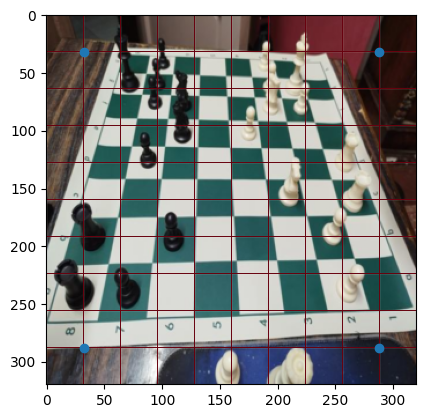

In [5]:
img, label = count_ds[278]
grid = np.zeros(img.shape[1:], dtype=np.float32)
plt.imshow(img.permute(1,2,0));
plt.scatter(np.array([32, 288, 288,32]), np.array([32, 32, 288, 288]));
grid[::32, :] = 1
grid[:, ::32] = 1
plt.imshow(grid, alpha=grid, cmap="Reds")
label["image_path"], img.shape

In [6]:
ds = ChessDataset(
    config={
        "img_size": (640,640),
    },
    img_label_transforms = transforms.Compose([
            preprocess_fn(),
            augmentations_fn(),
        ]),
    force_build_pkl=True
)

train_ds, _, _ = ChessDataset.train_valid_test_split(ds, sizes=(.8,.1,.1), random_state=42)

train_dl = ChessDataset.getLoader(train_ds, 16, 2)
# valid_dl = ChessDataset.getLoader(valid_ds, 16, 2)
# test_dl = ChessDataset.getLoader(test_ds, 16, 2)

ds_noaugmentation = ChessDataset(
    config={
        "img_size": (640,640),
    },
    img_label_transforms = transforms.Compose([
            preprocess_fn(),
            # augmentations_fn(),
        ]),
    force_build_pkl=True
)

_, valid_ds, test_ds = ChessDataset.train_valid_test_split(ds_noaugmentation, sizes=(.8,.1,.1), random_state=42)

# train_dl = ChessDataset.getLoader(train_ds, 16, 2)
valid_dl = ChessDataset.getLoader(valid_ds, 16, 2)
test_dl = ChessDataset.getLoader(test_ds, 16, 2)

len(train_ds), len(valid_ds), len(test_ds)

(803, 99, 103)

torch.Size([8, 8, 3, 128, 64])


'/mnt/D/University/Thesis_Dataset/Dataset/Images/image_11.jpg'

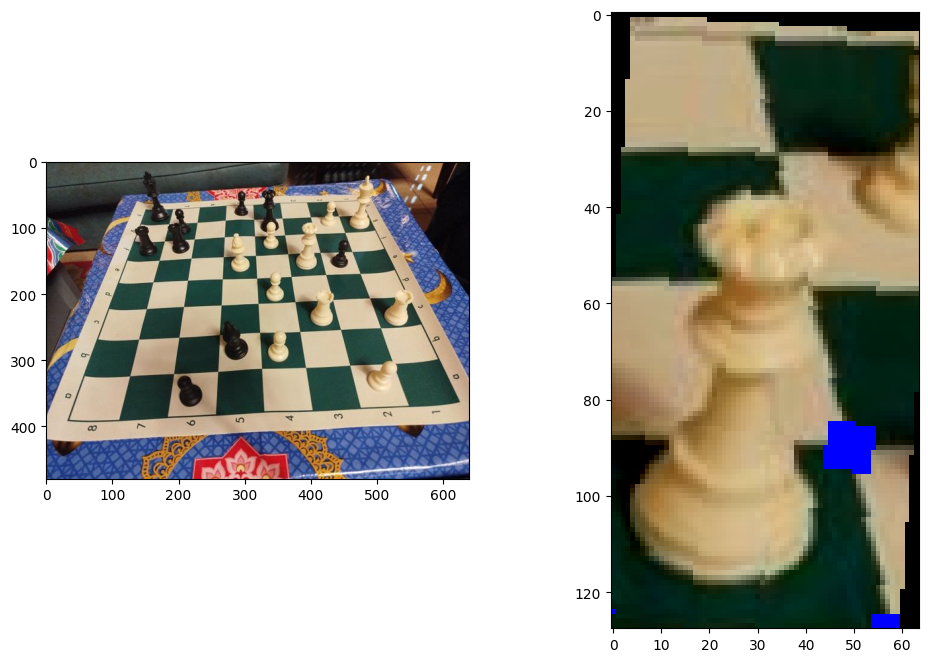

In [7]:
# board_split, y = ds[100]
# board_split, y = ds[200]
board_split, y = ds[10]

# grid = np.zeros((warpped.shape[1], warpped.shape[2]))
# step = 32
# # Set pixels in rows and columns that are multiples of step to 1
# grid[::step, :] = 1   # horizontal lines
# grid[:, ::step] = 1   # vertical lines

# plt.imshow(warpped.permute(1,2,0));
# plt.imshow(grid, alpha=grid, cmap='Reds');

print(board_split.shape)
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
plt.imshow(Image.open(y["image_path"]).convert("RGB"))
plt.subplot(1,2,2)
plt.imshow(board_split[3,5].permute(1,2,0));
y["image_path"]

In [8]:
class PieceDetectorCNNModel(nn.Module):
    def __init__(self, avg_embeds=None):
        super().__init__()

        self.avg_embeds=None
        if avg_embeds is not None:
            self.avg_embeds = avg_embeds

        self.latent_dim = 512

        self.resnet = models.resnet18(weights="ResNet18_Weights.DEFAULT")
        for param in self.resnet.parameters():
            param.requires_grad = False
        self.resnet = nn.Sequential(*list(self.resnet.children())[:-1])  # Remove the last FC layer and avgpool
        for param in self.resnet[-4:].parameters():
            param.requires_grad = True
        # self.backbone = self.resnet
        # self.backbone_dim = 512

        # self.efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        # for param in self.efficientnet.parameters():
        #     param.requires_grad = False
        # self.efficientnet = self.efficientnet.features  # Remove the last FC layer and avgpool
        # for param in self.efficientnet[-2:].parameters():
        #     param.requires_grad = True
        # self.backbone = self.efficientnet
        # self.backbone_dim = 1280

        dropporb = .2

        # self.conv1 = nn.Sequential(
        #     # 32, 32
        #     nn.Conv2d(3, 16, 3, padding=1),
        #     nn.LeakyReLU(),
        #     nn.BatchNorm2d(16),
        #     nn.MaxPool2d(4),
        #     nn.Dropout(dropporb),

        #     # 8, 8
        #     nn.Conv2d(16, 64, 3, padding=1),
        #     nn.LeakyReLU(),
        #     nn.BatchNorm2d(64),
        #     nn.MaxPool2d(4),
        #     nn.Dropout(dropporb),

        #     # 2,2
        #     nn.Conv2d(64, 128, 3, padding=1),
        #     nn.LeakyReLU(),
        #     nn.BatchNorm2d(128),
        #     nn.MaxPool2d(2),
        #     nn.Dropout(dropporb),

        #     # 1, 1
        # )

        self.conv1 = nn.Sequential(
            nn.Flatten(),
            # nn.Linear(self.backbone_dim, self.latent_dim),
            nn.Linear(512, self.latent_dim),
            nn.LeakyReLU(),

            # nn.AdaptiveAvgPool2d((1,1))
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(self.latent_dim, self.latent_dim, 3, padding=1),
            nn.LeakyReLU(),
            # nn.BatchNorm2d(self.latent_dim),
            # nn.AdaptiveAvgPool2d((8,8)),
            nn.Dropout(dropporb),

            nn.Conv2d(self.latent_dim, self.latent_dim, 3, padding=1),
            nn.LeakyReLU(),
            # nn.BatchNorm2d(self.latent_dim),
            # nn.AdaptiveAvgPool2d((8,8)),
            nn.Dropout(dropporb),

            nn.AdaptiveAvgPool2d((8,8))
        )

        self.classifier = nn.Sequential(
            # nn.Linear(128, 64),
            # nn.LeakyReLU(),
            # nn.Dropout(dropporb),
        )

        self.occupancy_classifier_heads = nn.Sequential(
            nn.Linear(self.latent_dim, 128),
            nn.LeakyReLU(),
            nn.Dropout(dropporb),
            nn.Linear(128, 1)
        )
        self.piece_color_classifier_heads = nn.Sequential(
            nn.Linear(self.latent_dim, 128),
            nn.LeakyReLU(),
            nn.Dropout(dropporb),
            nn.Linear(128, 1)
        )
        self.piece_type_classifier_heads = nn.Sequential(
            nn.Linear(self.latent_dim, 128),
            nn.LeakyReLU(),
            nn.Dropout(dropporb),
            nn.Linear(128, 6)
        )

        self.pos_emb = nn.Parameter(torch.zeros(self.latent_dim, 8, 8))
        self.sin_pos_emb = None  # [C, 8, 8]

    def sinusoidal_embeddings_2d(self, height=10, width=10):
        """
        Create 2D sinusoidal positional embeddings for an (H, W) grid.

        height, width: grid size
        d_model: total embedding dimension (should be even)

        Returns:
            pos_emb: [H, W, d_model] tensor
        """
        d_model = self.latent_dim
        if self.sin_pos_emb is not None and (tuple(self.sin_pos_emb.shape) == (d_model, height, width)):
            return self.sin_pos_emb

        if d_model % 4 != 0:
            raise ValueError("d_model must be divisible by 4 for 2D sin/cos.")

        # Position indices
        y_pos = torch.arange(height, dtype=torch.float32).unsqueeze(1)  # [H, 1]
        x_pos = torch.arange(width, dtype=torch.float32).unsqueeze(1)   # [W, 1]

        # Each axis gets d_model/2 dimensions, split into sin/cos → d_model/4 each
        d_model_half = d_model // 2
        div_term = torch.exp(torch.arange(0, d_model_half, 2).float() * (-math.log(10000.0) / d_model_half))

        # Row (y) embeddings
        pe_y = torch.zeros(height, d_model_half)
        pe_y[:, 0::2] = torch.sin(y_pos * div_term)
        pe_y[:, 1::2] = torch.cos(y_pos * div_term)

        # Col (x) embeddings
        pe_x = torch.zeros(width, d_model_half)
        pe_x[:, 0::2] = torch.sin(x_pos * div_term)
        pe_x[:, 1::2] = torch.cos(x_pos * div_term)

        # Combine row and col into [H, W, d_model]
        pe = torch.zeros(height, width, d_model)
        for i in range(height):
            for j in range(width):
                pe[i, j] = torch.cat([pe_y[i], pe_x[j]], dim=0)

        self.sin_pos_emb = pe.permute(2, 0, 1).to(device)
        return self.sin_pos_emb

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: B, 8,8,c,32,32
        # x = x.permute(0,3,1,2,4,5)

        sq_size = (x.shape[4],x.shape[5])
        B = x.shape[0]
        C = x.shape[3]
        if C != 3:
            raise Exception("Invalid Image")
        
        # board_split = x.reshape(B, C, 10, sq_size[0], 10, sq_size[1]).permute(0,1,2,4,3,5)
        # board_split = x

        # embeds = self.conv1(board_split.permute(0,2,3,1,4,5).reshape(-1,C,sq_size[0],sq_size[1])).squeeze(-1).squeeze(-1).reshape(B, 10,10, 128).permute(0,3,1,2)
        embeds = self.conv1(self.resnet(x.reshape(-1,C,sq_size[0],sq_size[1]))).squeeze(-1).squeeze(-1).reshape(B, 8,8, self.latent_dim).permute(0,3,1,2)

        sin_pos_emb = self.sinusoidal_embeddings_2d(8,8)

        # positioned_embeds = embeds + self.pos_emb + sin_pos_emb
        # positioned_embeds = embeds + sin_pos_emb
        positioned_embeds = embeds
        # attentioned_embeds = embeds.reshape(B, 10,10, 128).permute(0,3,1,2)
        attentioned_embeds = self.conv2(positioned_embeds)
        # cropped_attentioned_embeds = attentioned_embeds[:,:,1:9,1:9]
        attentioned_embeds = attentioned_embeds.permute(0,2,3,1).reshape(-1, self.latent_dim)
        attentioned_embeds = F.normalize(attentioned_embeds)

        if self.avg_embeds is None:
            res = self.classifier(attentioned_embeds)
            res_occupancy = self.occupancy_classifier_heads(res).reshape(B, 8,8)
            res_piece_color = self.piece_color_classifier_heads(res).reshape(B, 8,8)
            res_piece_type = self.piece_type_classifier_heads(res).reshape(B, 8,8, 6)

            return {
                "occupancy": res_occupancy,
                "piece_color": res_piece_color,
                "piece_type": res_piece_type,
                "square_embedings": attentioned_embeds
            }
        else:
            res = (-10*torch.cdist(attentioned_embeds, self.avg_embeds)).softmax(dim=1)
            res_occupancy = (1-res[:,12]).reshape(B, 8,8)
            res_piece_color = (res[:,:6].sum(dim=1)/(1-res[:,12])).reshape(B, 8,8)
            res_piece_type = (res[:,:12].reshape(-1,2,6).sum(dim=1)/(1-res[:,[12]])).reshape(B, 8,8, 6)
            return {
                "occupancy": res_occupancy,
                "piece_color": res_piece_color,
                "piece_type": res_piece_type,
                "square_embedings": attentioned_embeds
            }

In [9]:
model = PieceDetectorCNNModel().to(device)
# model.load_state_dict(torch.load("piece_cnn.pt"))
# model.load_state_dict(torch.load("best_model.pt"))

In [11]:
for x, l in train_dl:
    with torch.inference_mode():
        res = model(x.to(device))
    print(res["occupancy"].shape)
    print(res["piece_color"].shape)
    print(res["piece_type"].shape)
    # print(res.shape)
    # print(l)

    # plt.imshow(x[0].permute(1,2,0));
    break

torch.Size([16, 8, 8])
torch.Size([16, 8, 8])
torch.Size([16, 8, 8, 6])


In [10]:
def train(model: nn.Module, train_loader, valid_loader, lr=1e-3, epochs=30, relative_weights=(1,3,6)):
    model.train()
    
    optimzier = torch.optim.Adam(model.parameters(), lr=lr)
    # class_weights = 64/(torch.tensor([8,2,2,2,1,1,8,2,2,2,1,1,32]))
    class_weights = 6492/(6*torch.tensor([3399, 461, 530, 924, 448, 730], device=device))
    loss_fn_binary_occupancy = nn.BCEWithLogitsLoss(weight=torch.tensor((occupancy_count-occupied_count)/occupied_count, device=device))
    loss_fn_binary_color = nn.BCEWithLogitsLoss(weight=torch.tensor((occupied_count-white_count)/white_count, device=device))
    loss_fn_type = nn.CrossEntropyLoss(weight=class_weights)

    relative_weights = (1,3,6)

    piece_type_margin = .3
    piece_color_margin = .1

    tau = 1
    alpha_piece_type = tau - piece_type_margin
    beta_piece_type = tau + piece_type_margin
    alpha_piece_color = tau - piece_color_margin
    beta_piece_color = tau + piece_color_margin

    def loss_fn(preds: dict[str, torch.Tensor], y: dict[str, torch.Tensor]) -> torch.Tensor:
        loss: torch.Tensor = \
                relative_weights[0] * loss_fn_binary_occupancy(preds["occupancy"], y["occupancy"]) + \
                relative_weights[1] * loss_fn_binary_color(preds["piece_color"]*y["occupancy"], (y["piece_color"])*y["occupancy"]) + \
                relative_weights[2] * loss_fn_type(preds["piece_type"]*y["occupancy"].unsqueeze(1), (y["piece_type"]*y["occupancy"]).to(torch.long))
        loss /= sum(relative_weights)
        
        distances = torch.cdist(preds["square_embedings"], preds["square_embedings"], p=2)
        positive_losses_type = torch.clamp(distances - alpha_piece_type*tau, min=0)
        negative_losses_type = torch.clamp(beta_piece_type*tau - distances, min=0)

        positive_losses_color = torch.clamp(distances - alpha_piece_color*tau, min=0)
        negative_losses_color = torch.clamp(beta_piece_color*tau - distances, min=0)

        clip_mask_type = (y["square_types"].reshape(1,-1) == y["square_types"].reshape(-1,1)).int()
        tmp_color = (y["piece_color"] + 1) * y["occupancy"]
        clip_mask_color = (tmp_color.reshape(1,-1) == tmp_color.reshape(-1,1)).int()

        positive_loss_type = (positive_losses_type*clip_mask_type).sum() / clip_mask_type.sum()
        negative_loss_type = (negative_losses_type*(1-clip_mask_type)).sum() / (1-clip_mask_type).sum()

        positive_loss_color = (positive_losses_color*clip_mask_color).sum() / clip_mask_color.sum()
        negative_loss_color = (negative_losses_color*(1-clip_mask_color)).sum() / (1-clip_mask_color).sum()
        
        loss += (positive_loss_type + negative_loss_type + positive_loss_color + negative_loss_color)

        return loss

    tracked_train_loss = []
    tracked_valid_loss = []

    tracked_train_acc = {
        "occupancy": [],
        "piece_color": [],
        "piece_type": [],
    }

    tracked_valid_acc = {
        "occupancy": [],
        "piece_color": [],
        "piece_type": [],
    }

    best_loss = None
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        train_acc = {
            "occupancy": 0,
            "piece_color": 0,
            "piece_type": 0,
        }
        train_count = 0
        train_occupied_count = 0
        for X, L in tqdm(train_loader):
            y: torch.Tensor = L["board_tensor"]
            X: torch.Tensor = X.to(device)
            y: torch.Tensor = y.to(device)

            preds: torch.Tensor = model(X)
            preds["occupancy"] = preds["occupancy"].reshape(-1)
            preds["piece_color"] = preds["piece_color"].reshape(-1)
            preds["piece_type"] = preds["piece_type"].reshape(-1, 6)

            # y = y.reshape(-1, 13)
            y_occupancy = (y < 12).to(torch.float32).reshape(-1)
            y_piece_color = (y<6).to(torch.float32).reshape(-1)
            y_piece_type = (y%6).to(torch.float32).reshape(-1)
            # y_piece_type = F.one_hot(y_piece_type.to(torch.long), 6)
            y = {
                "occupancy": y_occupancy,
                "piece_color": y_piece_color,
                "piece_type": y_piece_type,
                "square_types": y,
            }

            optimzier.zero_grad()
            loss = loss_fn(preds, y)
            loss.backward()
            optimzier.step()

            train_loss += loss.item()
            train_count += X.shape[0]*8*8
            train_occupied_count += y_occupancy.sum().item()

            train_acc["occupancy"] += ((preds["occupancy"].sigmoid() > .5) == y_occupancy).sum().item()
            train_acc["piece_color"] += (((preds["piece_color"].sigmoid() > .5) == y_piece_color).to(torch.int8)*y_occupancy).sum().item()
            train_acc["piece_type"] += ((preds["piece_type"].softmax(dim=1).argmax(dim=1) == y_piece_type).to(torch.int8)*y_occupancy).sum().item()

        train_loss /= train_count
        train_acc["occupancy"] /= train_count
        train_acc["piece_color"] /= train_occupied_count
        train_acc["piece_type"] /= train_occupied_count


        model.eval()
        valid_loss = 0
        valid_acc = {
            "occupancy": 0,
            "piece_color": 0,
            "piece_type": 0,
        }
        valid_count = 0
        valid_occupied_count = 0
        with torch.inference_mode():
            for X, L in tqdm(valid_loader):
                y: torch.Tensor = L["board_tensor"]
                X: torch.Tensor = X.to(device)
                y: torch.Tensor = y.to(device)

                preds: torch.Tensor = model(X)
                preds["occupancy"] = preds["occupancy"].reshape(-1)
                preds["piece_color"] = preds["piece_color"].reshape(-1)
                preds["piece_type"] = preds["piece_type"].reshape(-1, 6)

                # y = y.reshape(-1, 13)
                y_occupancy = (y < 12).to(torch.float32).reshape(-1)
                y_piece_color = (y<6).to(torch.float32).reshape(-1)
                y_piece_type = (y%6).to(torch.float32).reshape(-1)
                # y_piece_type = F.one_hot(y_piece_type.to(torch.long), 6)
                y = {
                    "occupancy": y_occupancy,
                    "piece_color": y_piece_color,
                    "piece_type": y_piece_type,
                    "square_types": y,
                }

                loss = loss_fn(preds, y)

                valid_loss += loss.item()
                valid_count += X.shape[0]*8*8
                valid_occupied_count += y_occupancy.sum().item()

                valid_acc["occupancy"] += ((preds["occupancy"].sigmoid() > .5) == y_occupancy).sum().item()
                valid_acc["piece_color"] += (((preds["piece_color"].sigmoid() > .5) == y_piece_color).to(torch.int8)*y_occupancy).sum().item()
                valid_acc["piece_type"] += ((preds["piece_type"].softmax(dim=1).argmax(dim=1) == y_piece_type).to(torch.int8)*y_occupancy).sum().item()

            valid_loss /= valid_count
            valid_acc["occupancy"] /= valid_count
            valid_acc["piece_color"] /= valid_occupied_count
            valid_acc["piece_type"] /= valid_occupied_count

        if best_loss is None or valid_loss < best_loss:
            print(f"Valid Loss Improved: {best_loss} -> {valid_loss}")
            best_loss = valid_loss
            torch.save(model.state_dict(), "best_model.pt")

        tracked_train_loss.append(train_loss)
        tracked_valid_loss.append(valid_loss)

        tracked_train_acc["occupancy"].append(train_acc["occupancy"])
        tracked_train_acc["piece_color"].append(train_acc["piece_color"])
        tracked_train_acc["piece_type"].append(train_acc["piece_type"])

        tracked_valid_acc["occupancy"].append(valid_acc["occupancy"])
        tracked_valid_acc["piece_color"].append(valid_acc["piece_color"])
        tracked_valid_acc["piece_type"].append(valid_acc["piece_type"])

        torch.save(model.state_dict(), "last_model.pt")
        print(f"Epoch {epoch+1}/{epochs} |  Train Loss {train_loss:.4f} | Train Accuracy {train_acc["occupancy"]:.2f} {train_acc["piece_color"]:.2f} {train_acc["piece_type"]:.2f} | Valid Loss {valid_loss:.4f} | Valid Accuracy {valid_acc["occupancy"]:.2f} {valid_acc["piece_color"]:.2f} {valid_acc["piece_type"]:.2f}")

    plt.figure(figsize=(12,8))
    plt.subplot(1,4,1)
    plt.plot(range(epochs), tracked_train_loss, c="r");
    plt.plot(range(epochs), tracked_valid_loss, c='b');

    plt.subplot(1,4,2)
    plt.plot(range(epochs), tracked_train_acc["occupancy"], c='r');
    plt.plot(range(epochs), tracked_valid_acc["occupancy"], c='b');
    plt.subplot(1,4,3)
    plt.plot(range(epochs), tracked_train_acc["piece_color"], c='r');
    plt.plot(range(epochs), tracked_valid_acc["piece_color"], c='b');
    plt.subplot(1,4,4)
    plt.plot(range(epochs), tracked_train_acc["piece_type"], c='r');
    plt.plot(range(epochs), tracked_valid_acc["piece_type"], c='b');

  0%|          | 0/242 [00:00<?, ?it/s]

100%|██████████| 31/31 [00:18<00:00,  1.67it/s]


Valid Loss Improved: None -> 0.001369528232332079
Epoch 1/30 |  Train Loss 0.0015 | Train Accuracy 0.91 0.52 0.26 | Valid Loss 0.0014 | Valid Accuracy 0.98 0.51 0.34


100%|██████████| 31/31 [00:15<00:00,  1.99it/s]


Valid Loss Improved: 0.001369528232332079 -> 0.001205506573843609
Epoch 2/30 |  Train Loss 0.0013 | Train Accuracy 0.97 0.52 0.48 | Valid Loss 0.0012 | Valid Accuracy 0.97 0.54 0.59


...

Epoch 28/30 |  Train Loss 0.0006 | Train Accuracy 0.99 0.99 0.97 | Valid Loss 0.0007 | Valid Accuracy 0.99 0.99 0.95


100%|██████████| 31/31 [00:13<00:00,  2.30it/s]


Epoch 29/30 |  Train Loss 0.0006 | Train Accuracy 0.99 0.99 0.97 | Valid Loss 0.0007 | Valid Accuracy 0.99 0.99 0.95


100%|██████████| 31/31 [00:13<00:00,  2.32it/s]


Epoch 30/30 |  Train Loss 0.0006 | Train Accuracy 0.99 0.99 0.97 | Valid Loss 0.0007 | Valid Accuracy 0.99 0.99 0.95


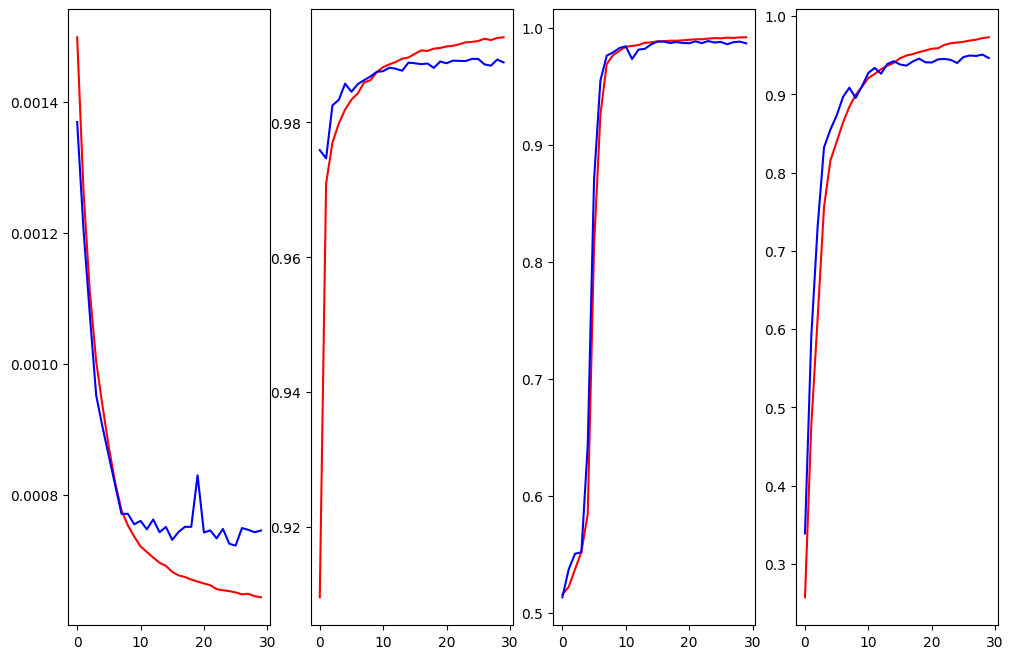

In [13]:
train(model, train_dl, valid_dl, epochs=30, lr=1e-3)

  0%|          | 0/193 [00:00<?, ?it/s]

100%|██████████| 24/24 [00:10<00:00,  2.32it/s]


Valid Loss Improved: None -> 0.0007719649906389982
Epoch 1/5 |  Train Loss 0.0007 | Train Accuracy 0.99 0.99 0.95 | Valid Loss 0.0008 | Valid Accuracy 0.98 0.98 0.93


100%|██████████| 24/24 [00:09<00:00,  2.42it/s]


Epoch 2/5 |  Train Loss 0.0007 | Train Accuracy 0.99 0.99 0.95 | Valid Loss 0.0008 | Valid Accuracy 0.98 0.98 0.93


...

Epoch 3/5 |  Train Loss 0.0007 | Train Accuracy 0.99 0.99 0.95 | Valid Loss 0.0008 | Valid Accuracy 0.98 0.98 0.93


100%|██████████| 24/24 [00:10<00:00,  2.34it/s]


Valid Loss Improved: 0.0007719649906389982 -> 0.0007640335420415471
Epoch 4/5 |  Train Loss 0.0007 | Train Accuracy 0.99 0.99 0.96 | Valid Loss 0.0008 | Valid Accuracy 0.98 0.98 0.93


100%|██████████| 24/24 [00:10<00:00,  2.23it/s]


Epoch 5/5 |  Train Loss 0.0007 | Train Accuracy 0.99 0.99 0.96 | Valid Loss 0.0008 | Valid Accuracy 0.98 0.98 0.94


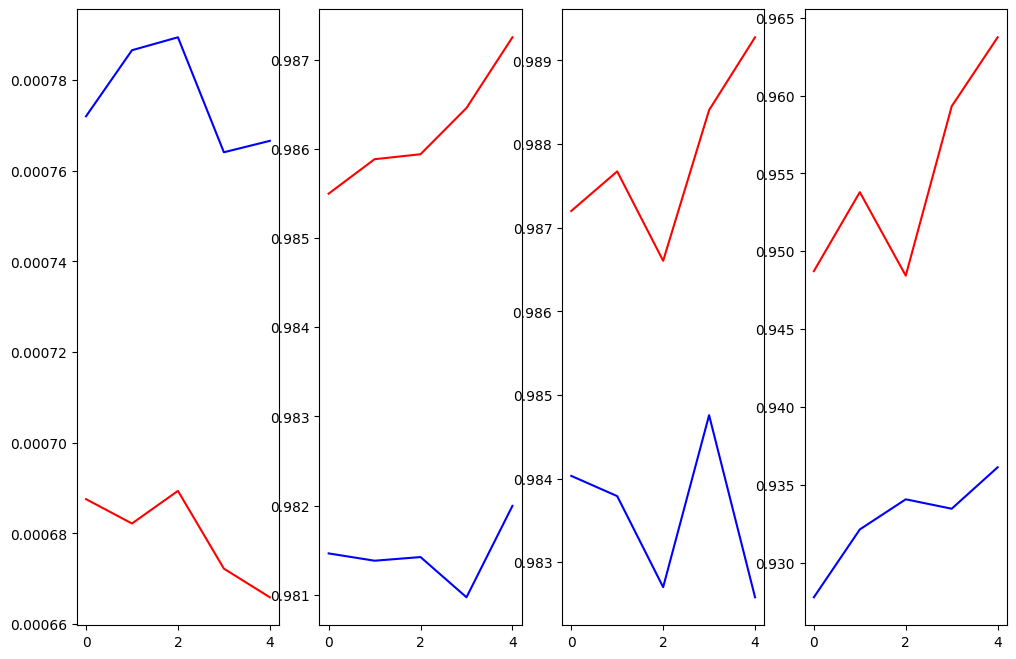

In [12]:
train(model, train_dl, valid_dl, epochs=5, lr=1e-3)

In [11]:
def test(model: nn.Module, test_loader, is_probs=False):
    model.eval()
    
    # class_weights = 64/(torch.tensor([8,2,2,2,1,1,8,2,2,2,1,1,32]))
    # loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(device))
    loss_fn_binary = nn.BCEWithLogitsLoss()
    loss_fn = nn.CrossEntropyLoss()

    combined_preds = {
        "occupancy": [],
        "piece_color": [],
        "piece_type": [],
        "all": []
    }
    combined_y = {
        "occupancy": [],
        "piece_color": [],
        "piece_type": [],
        "all": []
    }

    test_loss = 0
    test_acc = {
        "occupancy": 0,
        "piece_color": 0,
        "piece_type": 0,
        "all": 0
    }
    test_count = 0
    test_occupied_count = 0
    with torch.inference_mode():
        for X, L in tqdm(test_loader):
            y = L["board_tensor"]
            X = X.to(device)
            y = y.to(device)

            B = X.shape[0]

            preds: torch.Tensor = model(X)
            preds["occupancy"] = preds["occupancy"].reshape(-1)
            preds["piece_color"] = preds["piece_color"].reshape(-1)
            preds["piece_type"] = preds["piece_type"].reshape(-1, 6)

            # y = y.reshape(-1, 13)
            y_occupancy = (y < 12).to(torch.float32).reshape(-1)
            y_piece_color = (y<6).to(torch.float32).reshape(-1)
            y_piece_type = (y%6).to(torch.float32).reshape(-1)
            y = y.flatten()
            # y_piece_type = F.one_hot(y_piece_type.to(torch.long), 6)

            loss: torch.Tensor = loss_fn_binary(preds["occupancy"], y_occupancy) + \
                loss_fn_binary(preds["piece_color"]*y_occupancy, (y_piece_color)*y_occupancy) + \
                loss_fn(preds["piece_type"]*y_occupancy.unsqueeze(1), (y_piece_type*y_occupancy).to(torch.long))

            test_loss += loss.item()
            test_count += X.shape[0]*8*8
            test_occupied_count += y_occupancy.sum().item()

            if not is_probs:
                preds["occupancy"] = (preds["occupancy"].sigmoid())
                preds["piece_color"] = (preds["piece_color"].sigmoid())
                preds["piece_type"] = preds["piece_type"].softmax(dim=1)

            pred = torch.zeros(B*8*8, 13, device=device)
            pred[:,12] = 1-preds["occupancy"]
            pred[:,:6] = (preds["piece_type"] * preds["piece_color"].unsqueeze(1)) * (preds["occupancy"].unsqueeze(1))
            pred[:,6:12] = (preds["piece_type"] * (1-preds["piece_color"].unsqueeze(1))) * (preds["occupancy"].unsqueeze(1))
            
            preds["occupancy"] = preds["occupancy"] > .5
            preds["piece_color"] = preds["piece_color"] > .5
            preds["piece_type"] = preds["piece_type"].argmax(dim=1)
            pred = pred.argmax(dim=1)

            test_acc["occupancy"] += (preds["occupancy"] == y_occupancy).sum().item()
            test_acc["piece_color"] += ((preds["piece_color"] == y_piece_color).to(torch.int8)*y_occupancy).sum().item()
            test_acc["piece_type"] += ((preds["piece_type"] == y_piece_type).to(torch.int8)*y_occupancy).sum().item()
            test_acc["all"] += (pred == y).sum().item()

            combined_y["occupancy"].append(y_occupancy)
            combined_y["piece_color"].append(y_piece_color[y_occupancy>.5])
            combined_y["piece_type"].append(y_piece_type[y_occupancy>.5])
            combined_y["all"].append(y)

            combined_preds["occupancy"].append(preds["occupancy"])
            combined_preds["piece_color"].append(preds["piece_color"][y_occupancy>.5])
            combined_preds["piece_type"].append(preds["piece_type"][y_occupancy>.5])
            combined_preds["all"].append(pred)

        test_loss /= test_count
        test_acc["occupancy"] /= test_count
        test_acc["piece_color"] /= test_occupied_count
        test_acc["piece_type"] /= test_occupied_count
        test_acc["all"] /= test_count

        print(f"Loss {test_loss:.4f} | Accuracy {test_acc["occupancy"]:.2f} {test_acc["piece_color"]:.2f} {test_acc["piece_type"]:.2f} {test_acc["all"]:.2f}")

        combined_y["occupancy"] = torch.cat(combined_y["occupancy"]).cpu()
        combined_y["piece_color"] = torch.cat(combined_y["piece_color"]).cpu()
        combined_y["piece_type"] = torch.cat(combined_y["piece_type"]).cpu()
        combined_y["all"] = torch.cat(combined_y["all"]).cpu()

        combined_preds["occupancy"] = torch.cat(combined_preds["occupancy"]).cpu()
        combined_preds["piece_color"] = torch.cat(combined_preds["piece_color"]).cpu()
        combined_preds["piece_type"] = torch.cat(combined_preds["piece_type"]).cpu()
        combined_preds["all"] = torch.cat(combined_preds["all"]).cpu()

        cr1 = classification_report(combined_y["occupancy"], combined_preds["occupancy"], target_names=["Empty", "Occupied"])

        cr2 = classification_report(combined_y["piece_color"], combined_preds["piece_color"], target_names=["Black", "White"])
        
        cr3 = classification_report(combined_y["piece_type"], combined_preds["piece_type"], target_names=['Pawn', 'Knight', 'Bishop', 'Rook', 'Queen', 'King'])

        cr4 = classification_report(combined_y["all"], combined_preds["all"], target_names=['White-Pawn', 'White-Knight', 'White-Bishop', 'White-Rook', 'White-Queen', 'White-King', 'Black-Pawn', 'Black-Knight', 'Black-Bishop', 'Black-Rook', 'Black-Queen', 'Black-King', 'Empty'])

        print(cr1)
        print(cr2)
        print(cr3)
        print(cr4)

        cm = confusion_matrix(combined_y["all"], combined_preds["all"])

        correct = 0
        for i in range(13):
            correct += cm[i,i]
            cm[i,i] = 0
        print(f"Total Correct: {correct}/{combined_preds["all"].numel()}")
        print(f"Error Count: {cm.sum()}")

        plt.figure(figsize=(12,10))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['P', 'N', 'B', 'R', 'Q', 'K', 'p', 'n', 'b', 'r', 'q', 'k', 'Empty'])
        disp.plot(cmap='Blues', ax=plt.gca())

100%|██████████| 7/7 [00:05<00:00,  1.38it/s]


Loss 0.0019 | Accuracy 1.00 1.00 0.99 0.99
              precision    recall  f1-score   support

       Empty       1.00      1.00      1.00      4231
    Occupied       1.00      0.99      1.00      2105

    accuracy                           1.00      6336
   macro avg       1.00      1.00      1.00      6336
weighted avg       1.00      1.00      1.00      6336

              precision    recall  f1-score   support

       Black       1.00      1.00      1.00      1056
       White       1.00      1.00      1.00      1049

    accuracy                           1.00      2105
   macro avg       1.00      1.00      1.00      2105
weighted avg       1.00      1.00      1.00      2105

              precision    recall  f1-score   support

        Pawn       1.00      0.99      1.00      1079
      Knight       0.98      0.99      0.99       206
      Bishop       0.96      0.98      0.97       200
        Rook       0.99      0.99      0.99       276
       Queen       0.97      1.0

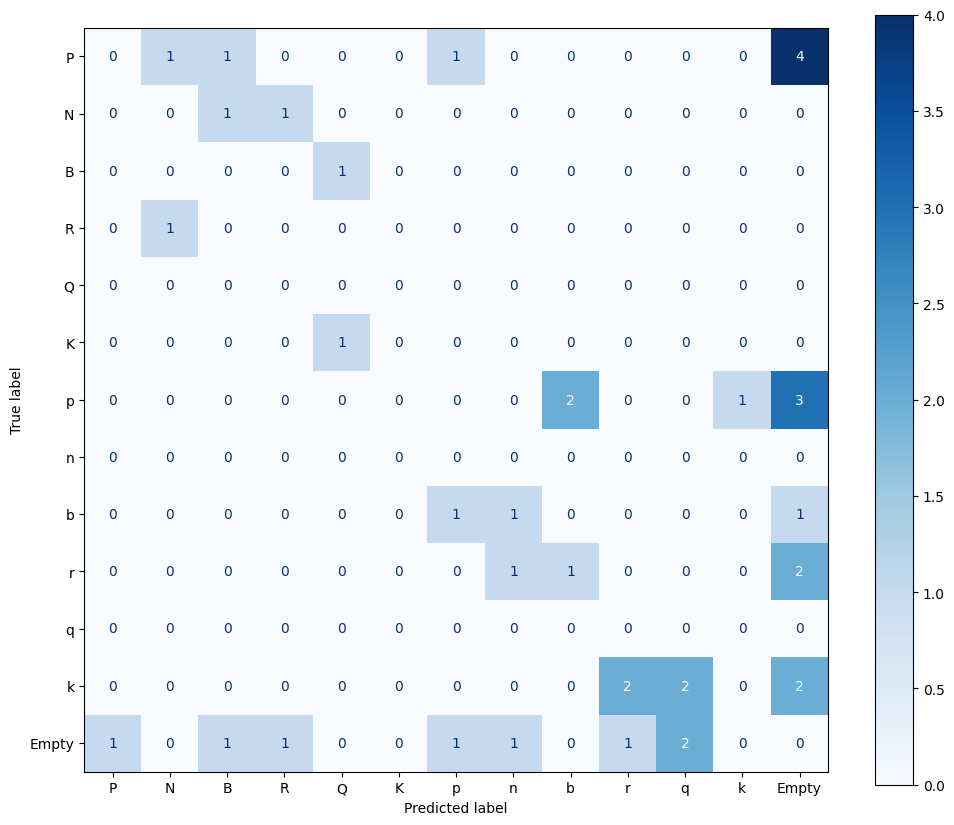

In [14]:
# model.load_state_dict(torch.load("best_model.pt"))
model.load_state_dict(torch.load("last_model.pt"))
# model.load_state_dict(torch.load("piece_cnn.pt"))
test(model, valid_dl)

In [ ]:
# 100%|██████████| 7/7 [00:14<00:00,  2.03s/it]Loss 0.0019 | Accuracy 0.99 0.99 0.94 0.96
#               precision    recall  f1-score   support

#        Empty       0.99      0.99      0.99      4307
#     Occupied       0.99      0.97      0.98      2285

#     accuracy                           0.99      6592
#    macro avg       0.99      0.98      0.98      6592
# weighted avg       0.99      0.99      0.99      6592

#               precision    recall  f1-score   support

#        Black       0.99      0.99      0.99      1144
#        White       0.99      0.99      0.99      1141

#     accuracy                           0.99      2285
#    macro avg       0.99      0.99      0.99      2285
# weighted avg       0.99      0.99      0.99      2285

#               precision    recall  f1-score   support

#         Pawn       0.98      0.96      0.97      1191
#       Knight       0.83      0.92      0.87       214
#       Bishop       0.86      0.88      0.87       202
#         Rook       0.93      0.91      0.92       324
#        Queen       0.92      0.91      0.91       148
#         King       0.96      0.93      0.94       206

#     accuracy                           0.94      2285
#    macro avg       0.91      0.92      0.91      2285
# weighted avg       0.94      0.94      0.94      2285

#               precision    recall  f1-score   support

#   White-Pawn       0.95      0.95      0.95       588
# White-Knight       0.87      0.84      0.85       107
# White-Bishop       0.85      0.83      0.84       107
#   White-Rook       0.90      0.87      0.88       161
#  White-Queen       0.90      0.85      0.88        75
#   White-King       0.96      0.94      0.95       103
#   Black-Pawn       0.98      0.92      0.95       603
# Black-Knight       0.78      0.97      0.87       107
# Black-Bishop       0.85      0.86      0.86        95
#   Black-Rook       0.93      0.88      0.91       163
#  Black-Queen       0.89      0.86      0.88        73
#   Black-King       0.94      0.91      0.93       103
#        Empty       0.98      0.99      0.99      4307

#     accuracy                           0.96      6592
#    macro avg       0.91      0.90      0.90      6592
# weighted avg       0.96      0.96      0.96      6592

# Get Avg Embeds for classes

In [24]:
avg_embeds = None
counts = torch.zeros(13, device=device, dtype=torch.int32)
model.eval()
with torch.inference_mode():
    for X, L in tqdm(train_dl):
        y = L["board_tensor"]
        X = X.to(device)
        y = y.to(device)

        y = y.reshape(-1)

        preds: torch.Tensor = model(X)
        preds["occupancy"] = preds["occupancy"].reshape(-1)
        preds["piece_color"] = preds["piece_color"].reshape(-1)
        preds["piece_type"] = preds["piece_type"].reshape(-1, 6)
        # preds["square_embedings"] = preds["square_embedings"] # B*8*8, 512

        if avg_embeds is None:
            avg_embeds = torch.zeros(13,preds["square_embedings"].shape[1], device=device, dtype=torch.float32)
        
        for i in range(13):
            avg_embeds[i] += preds["square_embedings"][y==i].sum(dim=0)
            counts[i] += (y==i).sum()

avg_embeds = avg_embeds / counts.unsqueeze(1)
avg_embeds.shape

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:32<00:00,  1.65s/it]


torch.Size([13, 512])

In [ ]:
model = PieceDetectorCNNModel(avg_embeds).to(device)
model.load_state_dict(torch.load("best_model.pt"))
# model.load_state_dict(torch.load("last_model.pt"))
test(model, test_dl, True)

/mnt/D/University/Thesis/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/D/University/Thesis/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 3/3 [00:09<00:00,  3.09s/it]

Loss 0.0034 | Accuracy 0.99 0.94 0.90 0.96
              precision    recall  f1-score   support

       Empty       1.00      1.00      1.00      1853
    Occupied       0.99      0.99      0.99       707

    accuracy                           0.99      2560
   macro avg       0.99      0.99      0.99      2560
weighted avg       0.99      0.99      0.99      2560

              precision    recall  f1-score   support

       Black       0.94      0.94      0.94       352
       White       0.94      0.94      0.94       355

    accuracy                           0.94       707
   macro avg       0.94      0.94      0.94       707
weighted avg       0.94      0.94      0.94       707

              precision    recall  f1-score   support

        Pawn       0.99      0.96      0.98       385
      Knight       0.56      0.82      0.67        44
      Bishop       0.80      0.80      0.80        40
        Rook       0.81      0.82      0.82       102
       Queen       0.86      0.8

## Old Test

In [12]:
from Utils import ChessUtils

In [13]:
f = ds[0][1]["fen"]
ChessUtils.ChessTensorUtils().FENtoTensor(f).permute(0,2,3,1)[0,0,0]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

In [14]:
cu = ChessUtils.ChessTensorUtils()

In [15]:
cu = ChessUtils.ChessTensorUtils()
with open("../data/data_manual/full_dataset/annotations_manual.pkl", "rb") as f:
    x = pickle.load(f)

for i in range(len(x)):
    x[i]["y"] = cu.FENtoTensor(x[i]["fen"]).permute(0,2,3,1).squeeze().rot90(-1, (0,1))

with open("../data/data_manual/full_dataset/annotations_manual_2.pkl", "wb") as f:
    pickle.dump(x, f)

FileNotFoundError: [Errno 2] No such file or directory: '../data/data_manual/full_dataset/annotations_manual.pkl'

(tensor([[ 3, 12, 12,  0, 12, 12,  6,  9],
         [12,  0, 12, 12, 12, 12,  6, 12],
         [ 2, 12,  1, 12,  6, 12, 12,  8],
         [ 4,  0, 12, 12,  6, 12,  7, 10],
         [12,  0, 12, 12, 12,  6, 12, 11],
         [ 3,  0, 12, 12, 12, 12,  6,  8],
         [ 5,  2,  0, 12, 12, 12,  6, 12],
         [12,  0, 12, 12, 12, 12,  6,  9]]),
 '../data/data_manual/full_dataset/manual_dataset/images/img1.jpg',
 tensor(2))

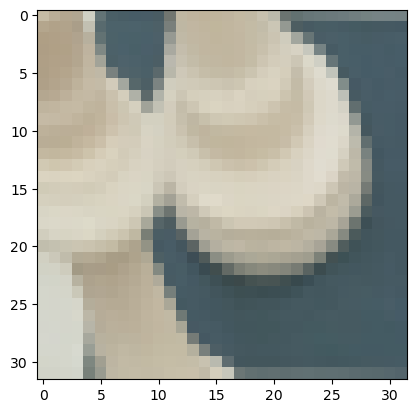

In [ ]:
x, y = ds[0]

x = x.unsqueeze(0)

sq_size = (x.shape[2]//10, x.shape[3]//10)
B = x.shape[0]
C = x.shape[1]
if C != 3:
    raise Exception("Invalid Image")

board_split = x.reshape(B, C, 10, sq_size[0], 10, sq_size[1]).permute(0,1,2,4,3,5)

plt.imshow(board_split[0,:,3,1,:,:].permute(1,2,0));

y['y'].argmax(dim=2), y['file_path'], y['y'].argmax(dim=2)[2,0]

In [ ]:
with torch.inference_mode():
    x = ds[0][0].unsqueeze(0).to(device)
    preds = model(x)
preds.shape

torch.Size([1, 8, 8, 13])

In [ ]:
board = preds.squeeze().argmax(2).rot90(1).unsqueeze(0)
print(board.shape)
cu.tensorToFEN_MAX(board)

torch.Size([1, 8, 8])


'r1bqkb1r/pp1n1ppp/4p3/2pp4/P7/2B3P1/1P1NP1BP/R1BQ1RK1'

In [ ]:
img = Image.open("../data/data_old/9.jpeg").convert("RGB").resize((640,640))
img = ds.transforms(img)

with torch.inference_mode():
    x = img.unsqueeze(0).to(device)
    preds = model(x)

board = preds.squeeze().argmax(2).rot90(1).unsqueeze(0)
cu.tensorToFEN_MAX(board)

'3r1r1r/pp2kQpp/2ppn3/1pP1n1P1/7P/3QP3/P4R2/RQ2R2R'